In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [8]:
cumulative = pd.read_csv("...//datasets//cumulative.csv",delimiter=",",header=53)
cumulative.head(5)

,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [10]:
cumulative.describe()

,kepid,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
count,9.564000e+03,8054.000000,9564.000000,9564.000000,9564.000000,9564.000000,9564.000000,9110.000000,9110.000000,9564.000000,...,9081.000000,9201.000000,9096.000000,9096.000000,9201.000000,9096.000000,9096.000000,9564.000000,9564.000000,9563.000000
mean,7.690628e+06,0.480829,0.208595,0.232748,0.197512,0.120033,75.671358,0.002148,-0.002148,166.183251,...,-162.265059,4.310157,0.120738,-0.143161,1.728712,0.362292,-0.394806,292.060163,43.810433,14.264606
std,2.653459e+06,0.476928,4.767290,0.422605,0.398142,0.325018,1334.744046,0.008236,0.008236,67.918960,...,72.746348,0.432606,0.132837,0.085477,6.127185,0.930870,2.168213,4.766657,3.601243,1.385448
min,7.574500e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.241843,0.000000,-0.172500,120.515914,...,-1762.000000,0.047000,0.000000,-1.207000,0.109000,0.000000,-116.137000,279.852720,36.577381,6.966000
25%,5.556034e+06,0.000000,0.000000,0.000000,0.000000,0.000000,2.733684,0.000005,-0.000276,132.761718,...,-198.000000,4.218000,0.042000,-0.196000,0.829000,0.129000,-0.250000,288.660770,40.777173,13.440000
50%,7.906892e+06,0.334000,0.000000,0.000000,0.000000,0.000000,9.752831,0.000035,-0.000035,137.224595,...,-160.000000,4.438000,0.070000,-0.128000,1.000000,0.251000,-0.111000,292.261125,43.677504,14.520000
75%,9.873066e+06,0.998000,0.000000,0.000000,0.000000,0.000000,40.715178,0.000276,-0.000005,170.694603,...,-114.000000,4.543000,0.149000,-0.088000,1.345000,0.364000,-0.069000,295.859160,46.714611,15.322000
max,1.293514e+07,1.000000,465.000000,1.000000,1.000000,1.000000,129995.778400,0.172500,0.000000,1472.522306,...,0.000000,5.364000,1.472000,0.000000,229.908000,33.091000,0.000000,301.720760,52.336010,20.003000


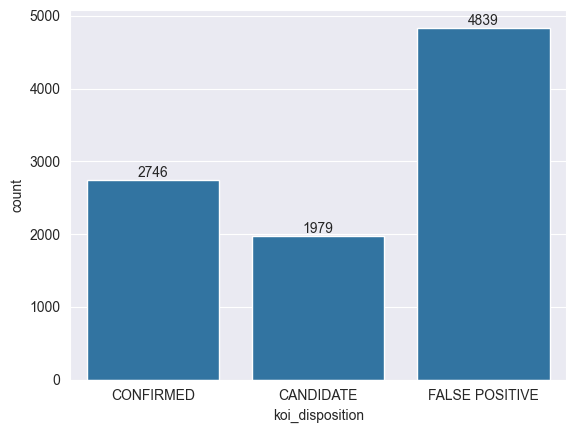

In [12]:
ax = sns.countplot(data=cumulative, x="koi_disposition")
ax.bar_label(ax.containers[0])
plt.show()

In [13]:
# On fait un dataframe avec les colonnes pour l'analyse PUIS on enlève les CANDIDATE qui seront tester à la fin :

cumulative_filtered = cumulative[[
    "koi_disposition",
    "koi_model_snr",
    "koi_srad",
    "koi_period",
    "koi_impact",
    "koi_duration",
    "koi_depth",
    "koi_prad",
    "koi_teq",
    "koi_insol",
    "koi_steff",
    "koi_slogg",
]]



cumulative_filtered.head()


,koi_disposition,koi_model_snr,koi_srad,koi_period,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_steff,koi_slogg
0,CONFIRMED,35.8,0.927,9.488036,0.146,2.95750,615.8,2.26,793.0,93.59,5455.0,4.467
1,CONFIRMED,25.8,0.927,54.418383,0.586,4.50700,874.8,2.83,443.0,9.11,5455.0,4.467
2,CANDIDATE,76.3,0.868,19.899140,0.969,1.78220,10829.0,14.60,638.0,39.30,5853.0,4.544
3,FALSE POSITIVE,505.6,0.791,1.736952,1.276,2.40641,8079.2,33.46,1395.0,891.96,5805.0,4.564
4,CONFIRMED,40.9,1.046,2.525592,0.701,1.65450,603.3,2.75,1406.0,926.16,6031.0,4.438


In [14]:
# Entraînement (CONFIRMED + FALSE POSITIVE)
cumulative_train = cumulative_filtered[
    cumulative_filtered["koi_disposition"].isin(["CONFIRMED", "FALSE POSITIVE"])
].copy()

cumulative_train = cumulative_train.dropna()

# Candidats à prédire
cumulative_candidates = cumulative_filtered[
    cumulative_filtered["koi_disposition"] == "CANDIDATE"
].copy()

cumulative_candidates = cumulative_candidates.dropna()

cumulative_train['koi_disposition'] = cumulative_train['koi_disposition'].map({'CONFIRMED':1,'FALSE POSITIVE':0})


In [15]:
y = cumulative_train['koi_disposition'].copy()
X = cumulative_train.drop(['koi_disposition'],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

koi_disposition
0    0.625427
1    0.374573
Name: proportion, dtype: float64
koi_disposition
0    0.625512
1    0.374488
Name: proportion, dtype: float64


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93       917
           1       0.87      0.89      0.88       549

    accuracy                           0.91      1466
   macro avg       0.90      0.90      0.90      1466
weighted avg       0.91      0.91      0.91      1466



<Axes: >

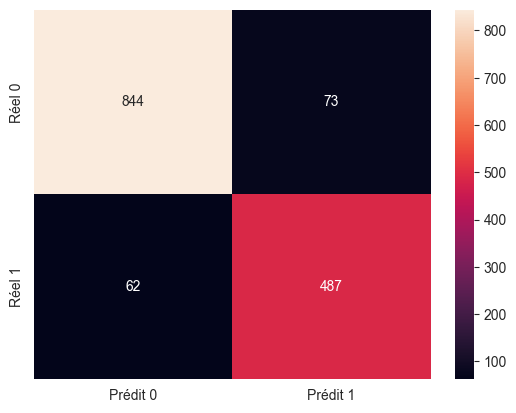

In [17]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,xticklabels=["Prédit 0","Prédit 1"], yticklabels=["Réel 0","Réel 1"], annot=True, fmt="d")

In [18]:
clf.feature_importances_

array([0.15252476, 0.03593668, 0.10196377, 0.1064936 , 0.07909739,
       0.08211569, 0.2018515 , 0.07527385, 0.09307585, 0.04000792,
       0.03165898])

<Axes: ylabel='feature'>

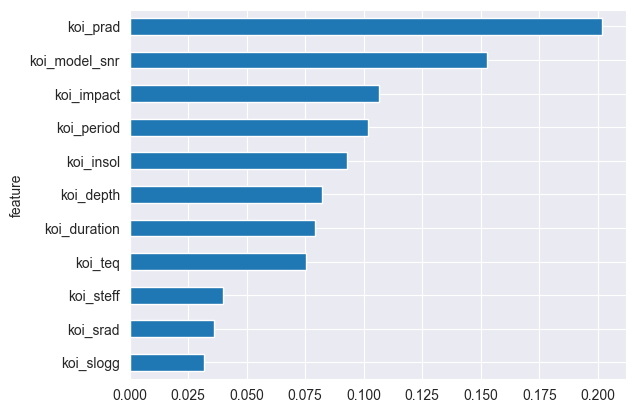

In [19]:
importance = pd.DataFrame({"feature": X_train.columns,"importance": clf.feature_importances_})

importance_sorted = importance.sort_values("importance")

importance_sorted.plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False
)

In [20]:
cumulative_candidates.head(10)

,koi_disposition,koi_model_snr,koi_srad,koi_period,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_steff,koi_slogg
2,CANDIDATE,76.3,0.868,19.899140,0.9690,1.7822,10829.0,14.60,638.0,39.30,5853.0,4.544
58,CANDIDATE,36.9,0.781,40.419504,0.9110,3.3620,6256.0,7.51,467.0,11.29,5446.0,4.507
62,CANDIDATE,13.7,0.765,7.240661,1.1980,0.5580,556.4,19.45,734.0,68.63,5005.0,4.595
63,CANDIDATE,8.7,1.087,3.435916,0.6240,3.1330,23.2,0.55,1272.0,617.61,5779.0,4.339
84,CANDIDATE,183.6,0.836,10.181584,0.9200,3.5089,5741.1,7.73,812.0,102.91,5988.0,4.541
92,CANDIDATE,340.5,0.905,19.620347,0.4580,2.0038,21725.0,13.60,643.0,40.39,5710.0,4.492
112,CANDIDATE,76.8,0.871,34.843986,0.9340,2.9315,4523.6,7.61,511.0,16.10,5509.0,4.482
118,CANDIDATE,296.9,0.826,4.640900,1.2800,35.5120,2450.6,30.09,1155.0,421.08,6463.0,4.500
123,CANDIDATE,89.6,0.990,1.028437,1.5734,1.8606,8098.0,72.77,1947.0,3400.48,6228.0,4.428
166,CANDIDATE,271.8,0.657,235.998640,0.7780,8.2284,20715.0,10.59,188.0,0.29,4245.0,4.627


In [21]:
X_candidates = cumulative_candidates.drop(['koi_disposition'],axis=1)

pred_candidates  = clf.predict_proba(X_candidates)
print(pred_candidates)

[[0.97 0.03]
 [0.6  0.4 ]
 [0.59 0.41]
 ...
 [0.89 0.11]
 [0.98 0.02]
 [1.   0.  ]]


In [22]:
cumulative_name = cumulative[cumulative["koi_disposition"] == "CANDIDATE"].copy()
cumulative_name = cumulative_name["kepoi_name"]
cumulative_name = cumulative_name.dropna()

In [23]:
# Créer un DataFrame avec les probabilités
results = pd.DataFrame(pred_candidates, columns=["prob_false", "prob_true"])

# Réinitialiser l'index de cumulative_name pour l'alignement
cumulative_name = cumulative_name.reset_index(drop=True)

# Associer les noms aux probabilités
results["kepoi_name"] = cumulative_name

# Réorganiser les colonnes
results = results[["kepoi_name", "prob_false", "prob_true"]]

print(results.head())

  kepoi_name  prob_false  prob_true
0  K00753.01        0.97       0.03
1  K00777.01        0.60       0.40
2  K00780.02        0.59       0.41
3  K00115.03        0.88       0.12
4  K00797.01        0.80       0.20


In [24]:
results_sorted = results.sort_values("prob_true", ascending=False)
print(results_sorted.head(10))

top_candidates = results_sorted[results_sorted["prob_true"] > 0.95]
print(f"Nombre de candidats très prometteurs : {len(top_candidates)} sur un total de {len(cumulative_candidates)} candidats")



    kepoi_name  prob_false  prob_true
336  K02924.02        0.00       1.00
626  K00750.02        0.00       1.00
355  K04288.04        0.00       1.00
42   K01206.01        0.01       0.99
131  K02052.01        0.01       0.99
57   K01255.01        0.01       0.99
342  K02926.05        0.01       0.99
209  K02657.01        0.01       0.99
121  K01549.01        0.02       0.98
146  K01945.02        0.02       0.98
Nombre de candidats très prometteurs : 36 sur un total de 1875 candidats


In [25]:
scatter_plot_df = results_sorted.reset_index(drop=True).join(
    X_candidates.reset_index(drop=True)
)

scatter_filtered = scatter_plot_df[
    (scatter_plot_df["koi_prad"] < 30) &
    (scatter_plot_df["koi_insol"] < 10000)
]

px.scatter(
    data_frame=scatter_filtered,
    log_x=True,
    log_y=True,
    height=600,
    x="koi_insol",
    y="koi_prad",
    color="prob_true",
    size="prob_true",
    hover_name="kepoi_name",
    hover_data=["koi_period","koi_teq","prob_true"],
    color_continuous_scale="RdYlGn",
)
